**I. INTRODUCTION**

For our second project, our team decided to analyze the same data set we used in our first project called Employee Salaries - 2022. The data set source is from the data Montgomery portal which seeks to provide open access to the County's data as outlined by the MD Public Information Act(MPIA). The dataset includes 10100 rows (observations) and 8 variables, satisfying the assignment requirement of having more than 1,000 observations. Each variable provides different dimensions of employee compensation and job attributes:

•	Department – Short code identifying the government department.

•	Department_Name – Full name of the department or agency.

•	Division: Specific operational unit within each department.

•	Gender: Gender of the employee (Male/Female).

•	Base Salary: Annual base pay listed for the employee.

•	Overtime Pay: Overtime compensation (when applicable).

•	Longevity Pay: Additional pay based on years of service.

•	Grade: Pay grade classification reflecting seniority or position level.

This data set therefore provides a rich opportunity to explore relationships between employee demographics, job level, and salary outcomes.
Based on the variables available, the main research question we agreed to explore is wether the department is a predictor of an employee making above $90000. Beside this main question we will also visualize:

•	The employees ditribution by gender in the top 10 departments

•	The base salary distribution in the top 10 department

•	An the base salary distribution by gender




MAIN RESEARCH QUESTION-- How does Department affect likelihood of high salary level?

Based on our previous project, we found that certain departments had higher median base salaries and varying distribution of base salaries. We also found that the highest paying departments tended to have more male employees compared to female employees. For this project we decided to build on those observations and test them with statistical analysis. In order to answer the question of how the department employed in affects your salary level, we decided to peform a logistic regression, which the top 10 departments by employee count as the categorical explanatory variable, and whether or not the employee makes above $90000 per year. In this way,  could explore whether an employee's department was a strong predictor of their likelihood to earn a high salary.  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
sal=pd.read_csv('/content/drive/MyDrive/Project 1 Data 201/Employee_salaries.csv')

In [ ]:
sal=pd.read_csv('/content/drive/MyDrive/Project 1 Data 201/Employee_salaries.csv')

**# II. Data Preparation, Wrangling and EDA**

**Quick Data Set Inspection**

In [ ]:
print(sal.head())

  Department                               Department_Name  \
0        ZAH  Office of Zoning and Administrative Hearings   
1        ZAH  Office of Zoning and Administrative Hearings   
2        ZAH  Office of Zoning and Administrative Hearings   
3        ZAH  Office of Zoning and Administrative Hearings   
4        ZAH  Office of Zoning and Administrative Hearings   

                                            Division Gender  Base Salary  \
0          ZAH 05 Zoning and Administrative Hearings      M     $142,100   
1          ZAH 05 Zoning and Administrative Hearings      F     $162,000   
2          ZAH 05 Zoning and Administrative Hearings      F      $93,895   
3  ZAH 05 Office of Zoning and Administrative Hea...      F   $77,179.61   
4                                    ZAH 05 Director      F  $196,631.58   

  Overtime Pay Longevity Pay Grade  
0          NaN           NaN   N35  
1          NaN           NaN   N35  
2          NaN           NaN   N21  
3          NaN        

In [ ]:
sal.info() #8 variables, Overtime pay and longevity pay have a significant amount of nas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10052 entries, 0 to 10051
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Department       10052 non-null  object
 1   Department_Name  10052 non-null  object
 2   Division         10052 non-null  object
 3   Gender           10052 non-null  object
 4   Base Salary      10052 non-null  object
 5   Overtime Pay     5786 non-null   object
 6   Longevity Pay    2399 non-null   object
 7   Grade            10013 non-null  object
dtypes: object(8)
memory usage: 628.4+ KB


**Exploring for Null values **

In [ ]:
sal.isnull().sum() #amount of nas

,0
Department,0
Department_Name,0
Division,0
Gender,0
Base Salary,0
Overtime Pay,4266
Longevity Pay,7653
Grade,39


**Converting Base Salary, Longevity Salary and Overtime Salary to floats**

In [ ]:
sal["Base Salary"] = (
    sal["Base Salary"]
    .str.replace("$", "")
    .str.replace(",", "")
    .astype(float))
sal["Overtime Pay"] = (
    sal["Overtime Pay"]
    .str.replace("$", "")
    .str.replace(",", "")
    .astype(float))
sal["Longevity Pay"] = (
    sal["Longevity Pay"]
    .str.replace("$", "")
    .str.replace(",", "")
    .astype(float))

**Preparing the data for Logistic Regression**

In [ ]:
#first we filter the top 10 deparments with the most employee count
top10_departments = sal[sal['Department_Name'].isin(sal['Department_Name'].value_counts().head(10).index)]
top10_departments.head()
#

,Department,Department_Name,Division,Gender,Base Salary,Overtime Pay,Longevity Pay,Grade
152,SHF,Sheriff's Office,SHF 48 Warrant Section,M,65234.0,2966.15,NaN,G3
153,SHF,Sheriff's Office,SHF 48 Warrant Section,M,65234.0,962.43,NaN,G3
154,SHF,Sheriff's Office,SHF 48 Warrant Section,M,69683.0,2110.50,NaN,G4
155,SHF,Sheriff's Office,SHF 48 Warrant Section,M,63082.0,3653.90,NaN,G3
156,SHF,Sheriff's Office,SHF 48 Warrant Section,M,63082.0,1928.22,NaN,G3


In [ ]:

final_df = top10_departments.loc[:,['Department','Department_Name','Base Salary']] #subsetting the dataset with the necessary columns
final_df["Binary Salary"] = np.where(final_df["Base Salary"] >= 90000, 1, 0) #creating a new column based on the $90,000 base salary threshold
final_df  #the final dataset

,Department,Department_Name,Base Salary,Binary Salary
152,SHF,Sheriff's Office,65234.00,0
153,SHF,Sheriff's Office,65234.00,0
154,SHF,Sheriff's Office,69683.00,0
155,SHF,Sheriff's Office,63082.00,0
156,SHF,Sheriff's Office,63082.00,0
...,...,...,...,...
10047,ABS,Alcohol Beverage Services,66642.71,0
10048,ABS,Alcohol Beverage Services,130359.90,1
10049,ABS,Alcohol Beverage Services,102500.00,1
10050,ABS,Alcohol Beverage Services,136017.23,1


Descriptive Statistics for Numerical Variables

In [ ]:
sal.describe() #descriptive statistics for numeric variables

,Base Salary,Overtime Pay,Longevity Pay
count,10052.000000,5786.000000,2399.000000
mean,85503.279209,12745.667478,2867.608020
std,30653.817339,17515.354262,1555.883112
min,11147.240000,1.020000,28.540000
25%,65109.000000,1306.832500,1728.980000
50%,81770.000000,6609.040000,2640.860000
75%,102180.000000,16977.855000,3682.800000
max,275000.000000,204404.490000,8589.140000


Descriptive Statistics for Categorical Variables

In [ ]:
sal[['Department','Department_Name','Division','Gender','Grade']].describe()

,Department,Department_Name,Division,Gender,Grade
count,10052,10052,10052,10052,10013
unique,41,41,620,2,96
top,POL,Department of Police,HHS 60 School Health Services,M,P4
freq,1858,1858,368,5852,731


**III. EDA & Visualization**

**Visualization 1: Employee Count by Gender in Top 10 Departments**

In [ ]:
top_departments = sal['Department_Name'].value_counts().head(10).index #reduce to top 10

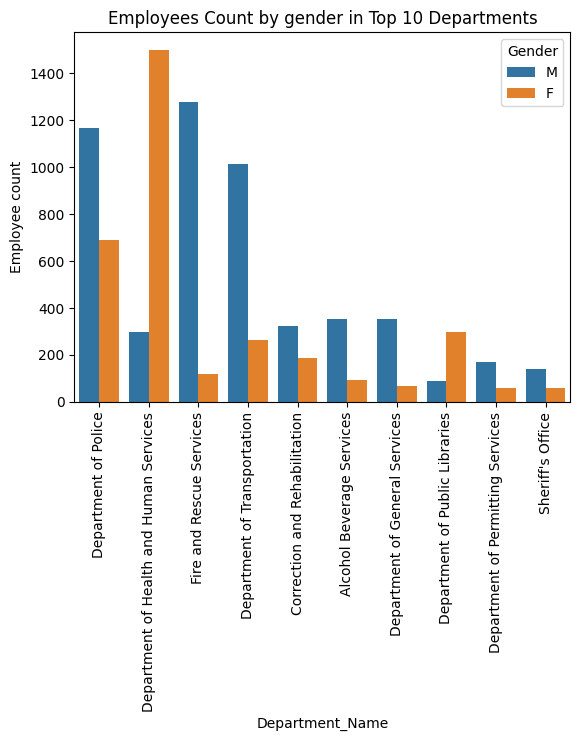

In [ ]:
sns.countplot(data=sal[sal['Department_Name'].isin(top_departments)],
              x='Department_Name',
              hue = 'Gender',
              order=top_departments)
plt.title("Employees Count by gender in Top 10 Departments")
plt.xticks(rotation=90)
plt.ylabel("Employee count")
plt.show()

From visualization # 1 above, we can conclude that there is a noticeable imbalance in gender representation across the top 10 departments. Departments such as the Department of Police, Department of Transportation, Sheriff's Office, and Fire Rescue Service show a significantly higher number of male employees compared to female employees. Conversely, some departments like Health and Human Services appear to have a more balanced or even a slightly higher number of female employees. This suggests that certain departments might be male-dominated, while others show more equitable or female-leaning distributions within the top employee counts.



**Visualization 2: Base Salary Distribution by top 10 department**



/tmp/ipython-input-224921162.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=sal, x='Department_Name', y='Base Salary', order = top_departments, palette = "coolwarm")


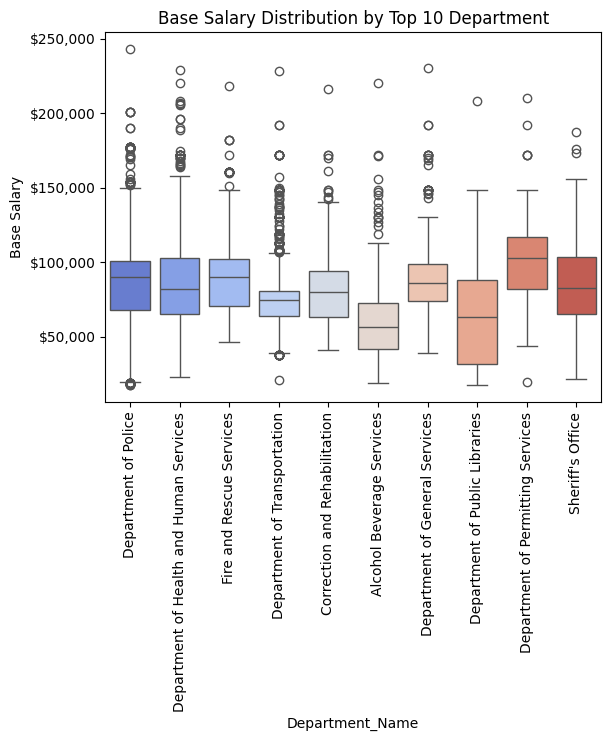

In [ ]:
ax = sns.boxplot(data=sal, x='Department_Name', y='Base Salary', order = top_departments, palette = "coolwarm")

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.title("Base Salary Distribution by Top 10 Department")
plt.xticks(rotation=90)
plt.show()

"Base Salary Distribution by Top 10 Department", shows several key aspects: The boxplot illustrates the spread and central tendency of 'Base Salary' for the top 10 departments. We can see variations in salary ranges and median salaries across different departments. Some departments might have a higher median base salary and a wider interquartile range (IQR), indicating a greater diversity in pay scales, while others might show a more concentrated salary distribution. Outliers, representing exceptionally high or low salaries within a department, are also visible. For instance, the Department of Police and Fire Rescue Service seem to have a broad range of salaries, including some higher earners. Departments like Health and Human Services also show a significant range. We can also identify departments with generally lower or higher salary ceilings and floors based on the whiskers and box boundaries.

# Picking a Threshold for "High Salary" Dummy Variable

We ended up picking a threshold of $90000 for our target binary variable due to the fact that it was roughly around the 3rd quartile across multiple departments as you can see in the Base Salary Distribution box and whisker plot above. This threshold would allow us to identify especially high earners in order to best explore our research question.

**Visualization 3: Base Salary Distribution by Gender**

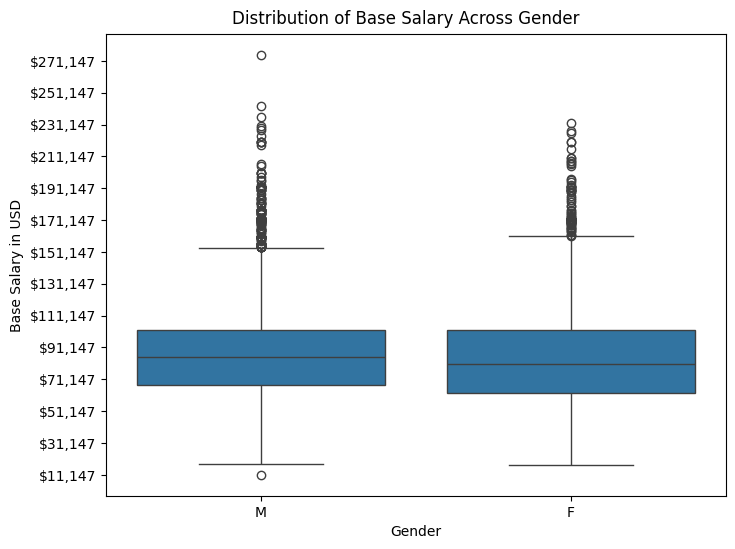

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6)) # Create a figure and an axes.

pl2 = sns.boxplot(x="Gender",
            y="Base Salary", # Use the numeric base salary data
            data=sal,
            ax=ax) # Plot on the created axes

# Adjust the y-axis ticks to be more frequent and set limits
y_min = sal['Base Salary'].min()
y_max = sal['Base Salary'].max()
y_ticks = np.arange(y_min, y_max, 20000) # Ticks every 20000 units from the min value to max value
ax.set_yticks(y_ticks)

#naming
fig.suptitle("Distribution of Base Salary Across Gender",  y=0.92)
pl2.set(xlabel = "Gender", ylabel = "Base Salary in USD")

# Format y-axis ticks with dollar sign and comma
from matplotlib.ticker import StrMethodFormatter
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}')) # Format as currency with no decimal places

plt.show()

In the above boxplot, the median base salary appears to be very similar for both genders, indicated by the horizontal lines within the boxes at roughly the same level.
However, the median base salary and quartiles 1 and 2 for male employees is slightly higher, and with a wider spread of data especially around the upper outliers. However the minimum is roughly the same across genders, probably due to minimum wage laws.
The interquartile range (IQR), represented by the height of the boxes, seems comparable for both genders. This suggests that the middle 50% of base salaries for both groups have a similar spread.
There appears to be some outliers with higher base salaries in both genders, represented by the individual points above the upper whiskers of the box plots.
The box plots suggests that the overall distribution of base salaries is quite similar between genders, at least in terms of central tendency and spread.

**Visualization 4: Employee count by the $90,000 Threshold**

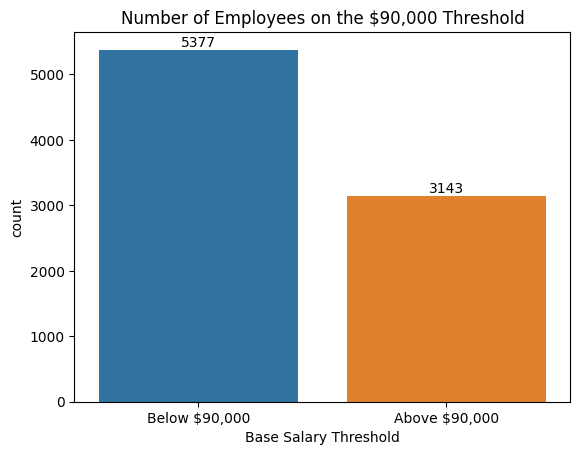

In [ ]:
ax = sns.countplot(x= "Binary Salary", data = final_df, hue = "Binary Salary", legend=False)
plt.xticks([0, 1], ['Below $90,000', 'Above $90,000'])
plt.xlabel("Base Salary Threshold")
plt.title("Number of Employees on the $90,000 Threshold")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

This plot shows the overall distribution of employees relative to the chosen $90,000 salary threshold. Given that the threshold was selected around the 3rd quartile, we would expect to see a larger number of employees in the Below $$90,000 salary threshold. This plots helps in understanding the scale and proportion of the category that the model is trying to predict.

**IV. Use scikit-learn Logistic Regression to train, test and predict that level of salary is determined by the department of work.**

**Import of scikit-learn**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score
)
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier


# Training, Test and Predict

In [ ]:
# -----------------------------------------
# Training
# Target: HighSalary (1 if Base Salary > 90,000, else 0)
# Predictor: Department
# -----------------------------------------
# 1. Define X (Department) and y (HighSalary)
# ============================
X = final_df[['Department_Name']]      # predictor: Department of work
y = final_df[['Binary Salary']]        # target: 1 = > 90k, 0 = ≤ 90k

# 2. Train–test split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 3. Preprocess + Logistic Regression model
# ============================
categorical_features = ['Department_Name']

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

log_reg = LogisticRegression(max_iter=1000)

clf_dept_90k = Pipeline(steps=[
    ("preprocess", preprocess),
    ("logreg", log_reg)
])

# Fit the model
clf_dept_90k.fit(X_train, y_train)
print("\nModel trained using only Department as predictor (threshold = 90,000).")


#brief prediction for model evaluation
y_pred = clf_dept_90k.predict(X_test)

y_proba = clf_dept_90k.predict_proba(X_test)[:, 1]




Model trained using only Department as predictor (threshold = 90,000).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**# Model Parameters**

In [ ]:
print('Classes', log_reg.classes_)
print('Intercept',log_reg.intercept_)
print("Coefficients", log_reg.coef_ )

Classes [0 1]
Intercept [-1.76629628]
Coefficients [[0.72954404 1.01597123 1.26014762 2.54526285 1.71552151 0.51464331
  0.09533945 1.72415971 1.61460019]]


# Evaluation Metrics: Accuracy, precision, recall, and f1-score

In [ ]:

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy of Department-only model (> 90k): {acc:.3f}")
print(f"ROC–AUC of Department-only model (> 90k): {auc:.3f}")

print("\nDetailed classification report (> 90k):")
print(classification_report(y_test, y_pred, digits=3))


Accuracy of Department-only model (> 90k): 0.635
ROC–AUC of Department-only model (> 90k): 0.657

Detailed classification report (> 90k):
              precision    recall  f1-score   support

           0      0.636     0.985     0.773      1344
           1      0.583     0.036     0.067       786

    accuracy                          0.635      2130
   macro avg      0.610     0.510     0.420      2130
weighted avg      0.617     0.635     0.512      2130



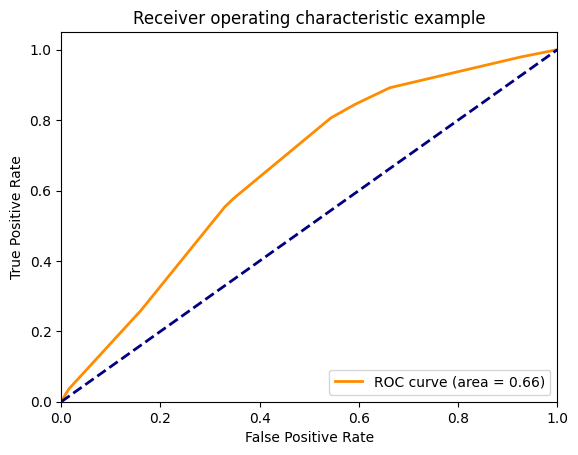

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = clf_dept_90k.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
        lw=2, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix

In [ ]:
conf_mat = confusion_matrix(y_test, y_pred)
conf_mat

array([[1324,   20],
       [ 758,   28]])

Text(0.5, 427.9555555555555, 'Predicted label')

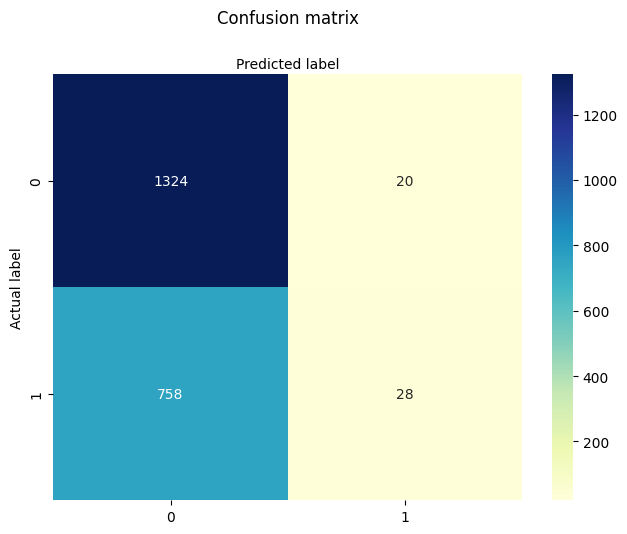

In [ ]:
categories = [0,1]
fig, ax = plt.subplots()
plt.xticks([0,1], categories)
plt.yticks([0,1], categories)
# create heatmap
sns.heatmap(pd.DataFrame(conf_mat), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

# Evaluating Metrics of the Model

The confusion matrix with TN=1324, FP=20, FN=758, and TP=28 shows that the model is overwhelmingly predicting that employees will not earn more than $90,000, and it is rarely flagging someone as a high earner. Overall accuracy is about 63.5%, but this number is misleading: the model’s recall on high earners is extremely low (it correctly identifies only about 3–4% of the people who actually earn more than $90,000), while its specificity for non–high earners is very high (about 98%). Precision for the positive class is moderate (around 58%), meaning that when the model does predict a salary above $90,000, it is often correct, but it almost never makes that prediction in the first place. The ROC AUC of 0.66 confirms that “department” alone has only weak discriminatory power for distinguishing employees above and below the $90,000 threshold.

To improve the model, there are two related tasks: threshold tuning and feature/model improvement. Threshold tuning could be used to increase recall by lowering the decision threshold for predicting “earns over $90,000,” accepting more false positives in exchange for catching more true high earners; we would explore different thresholds, examine the resulting confusion matrices, and pick an operating point that balances missing high earners versus incorrectly flagging lower earners. However, the modest ROC AUC suggests that even with an optimal threshold, department by itself is not a strong predictor of salary. To improve performance, we would likely need to incorporate additional features (for example, years of service, job title/rank, full-time vs. part-time status, overtime/other pay components, education, or location within the county) and possibly experiment with other models or schemes, then reevaluate with the same confusion-matrix.

# **V. Predict the classes of the test data. Predict the class probability of the test data**

Comparing Prediction Across Departments for 10 employees to Actual Results

In [ ]:
# Class predictions (0 or 1)
y_pred = clf_dept_90k.predict(X_test)

# Predicted probabilities for class 1 (HighSalary > 90k)
y_proba = clf_dept_90k.predict_proba(X_test)[:, 1]

In [ ]:
common_index = X_test[:10].index

department_series = X_test['Department_Name'].loc[common_index]
prediction_series = pd.Series(y_pred[:10], index=common_index, name='Prediction above 90k')
prediction_probability = pd.Series(y_proba[:10], index=common_index, name='Prediction Probability above 90k')
actual_series = y_test['Binary Salary'].loc[common_index]

data = {
    'Department': department_series,
    'Prediction above 90k': prediction_series,
    'Prediction Probability above 90k': prediction_probability,
    'Actual above 90k': actual_series
}

df = pd.DataFrame(data)
print(df)

                                   Department  Prediction above 90k  \
6588        Department of Permitting Services                     1   
6201                 Fire and Rescue Services                     0   
1472                     Department of Police                     0   
2957           Department of Public Libraries                     0   
8961            Correction and Rehabilitation                     0   
9219            Correction and Rehabilitation                     0   
4000  Department of Health and Human Services                     0   
7219             Department of Transportation                     0   
6215                 Fire and Rescue Services                     0   
9954                Alcohol Beverage Services                     0   

      Prediction Probability above 90k  Actual above 90k  
6588                          0.685457                 1  
6201                          0.489467                 1  
1472                          0.487309   

**VI.  Logistic Regression Prediction Results Interpretation**

So above is a table showing the prediction for a sample of 10 employees from varying departments. If the prediction probability was above .5, the regression predicted that the given employee made above 90k per year. We can compare these predicted results to the actual results in the test data and see that there is 1 true positive, 5 true negatives, and 4 false negatives.

# Conclusion (also for Mat)

This project demonstrates how logistic regression and standard Python tools (pandas, NumPy, scikit-learn, seaborn, and statsmodels) can be used to frame and evaluate a real-world prediction problem: estimating whether a county employee earns more than $90,000 based solely on department. The analysis shows that while department does carry some signal, it is not sufficient on its own to build a reliable classifier, especially if correctly identifying high earners is important. The workflow—data preparation, model fitting, and performance assessment via confusion matrices and ROC curves—provides a solid foundation; future work would extend this by enriching the feature set, refining the model, and tuning the decision threshold to better align the predictions with the practical goals and constraints of the county’s analysis.